# EDA — Augment Phase 1 (QA) — train / dev / test

Khảo sát **phân phối độ dài & nhãn** trên `data/processed/{train,dev,test}.csv` (đã augment).
Notebook này **CHỈ EDA — KHÔNG export/ghi đè dữ liệu**. Copy chức năng từ `eda_reasoning_flat`
(bỏ 2 cell export). Chạy lần lượt từng cell.

In [1]:
# === Setup: load 3 split + sinh cột (KHÔNG export) ===
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # tránh lỗi OpenMP (Windows/conda)
import json, re, sys, csv as _csv
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
_csv.field_size_limit(10**7)

def _find_root():
    for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (p / "data" / "processed").is_dir():
            return p
    raise RuntimeError("Không thấy project root (data/processed)")
ROOT = _find_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "processed"
HARD = ["A", "B", "C", "D", "Yes", "No", "Uncertain"]

def _jl(v, d):
    try: return json.loads(v) if isinstance(v, str) and v.strip() else d
    except Exception: return d

def load_splits():
    parts = []
    for sp in ("train", "dev", "test"):
        p = DATA / f"{sp}.csv"
        if not p.is_file(): print("[skip]", p); continue
        d = pd.read_csv(p, encoding="utf-8"); d["split"] = sp; parts.append(d)
    df = pd.concat(parts, ignore_index=True)
    for c in ("premises", "premises_fol", "options", "premises_used"):
        df[c] = df[c].apply(lambda v: _jl(v, []))
    df["reasoning"] = df["reasoning"].apply(lambda v: _jl(v, None))
    return df

def derive(df):
    df["n_premises_nl"]   = df["premises"].apply(len)
    df["n_premises_fol"]  = df["premises_fol"].apply(len)
    df["n_premises_used"] = df["premises_used"].apply(len)
    df["has_fol"]   = df["n_premises_fol"] > 0
    df["use_ratio"] = df.apply(lambda r: r["n_premises_used"]/r["n_premises_nl"] if r["n_premises_nl"] else np.nan, axis=1)
    df["label"] = df["answer_label"].astype(str).str.strip()
    def qtype(o):
        s = {str(x).strip() for x in (o or [])}
        if not o: return "Open/Other"
        return "Yes/No/Uncertain" if s == {"Yes", "No", "Uncertain"} else "MCQ"
    df["q_type"] = df["options"].apply(qtype)
    df["has_reasoning"] = df["reasoning"].apply(lambda r: bool(r))
    df["n_steps"] = df["reasoning"].apply(lambda r: len(r["steps"]) if r and r.get("steps") else 0)
    df["reasoning_type"] = df["reasoning"].apply(lambda r: r.get("type") if r else None)
    return df

df = derive(load_splits())
print("Loaded:", len(df), "| split:", dict(df["split"].value_counts()))
df.head(3)

Loaded: 799 | split: {'train': 643, 'dev': 78, 'test': 78}


,record_id,q_idx,n_premises_used,query,premises,options,answer,answer_label,explanation,premises_fol,...,split,n_premises_nl,n_premises_fol,has_fol,use_ratio,label,q_type,has_reasoning,n_steps,reasoning_type
0,0,0,1,Which conclusion follows with the fewest premi...,"[If a Python code is well-tested, then the pro...","[If a Python project is not optimized, then it...","If a Python project is not optimized, then it ...",A,Premise 0 states that if a Python project is w...,"[∀x (WT(x) → O(x)), ∀x (¬PEP8(x) → ¬WT(x)), ∀x...",...,train,14,14,True,0.071429,A,MCQ,True,3,fol
1,1,0,9,"Based on the above premises, which is the stro...",[Students who have completed the core curricul...,[Sophia qualifies for the university scholarsh...,Sophia qualifies for the university scholarship,A,Premises 6 and 7 confirm Sophia completed the ...,"[ForAll(x, (completed_core_curriculum(x) ∧ pas...",...,train,11,11,True,0.818182,A,MCQ,True,14,fol
2,2,0,9,"Based on the above premises, which conclusion ...",[Students who have completed the core curricul...,[Sophia qualifies for the university scholarsh...,Sophia qualifies for the university scholarship,A,Premises 6 and 7 confirm Sophia completed the ...,"[ForAll(x, (completed_core_curriculum(x) ∧ pas...",...,train,11,11,True,0.818182,A,MCQ,True,14,fol


## 0. Tổng quan

In [2]:
print("Tổng câu:", len(df), "| split:", dict(df["split"].value_counts()))
print("Có reasoning:", int(df["has_reasoning"].sum()), f"({df['has_reasoning'].mean():.1%})")
print("FOL coverage:", f"{df['has_fol'].mean():.1%}")
print("Loại câu:", dict(df["q_type"].value_counts()))
print("NL != FOL (có FOL):", int(((df["n_premises_nl"] != df["n_premises_fol"]) & df["has_fol"]).sum()))

Tổng câu: 799 | split: {'train': 643, 'dev': 78, 'test': 78}
Có reasoning: 799 (100.0%)
FOL coverage: 100.0%
Loại câu: {'Yes/No/Uncertain': 451, 'MCQ': 348}
NL != FOL (có FOL): 20


## 1. Phân phối premise (NL / FOL / used) + use_ratio


--- [train] n=643 ---
premise NL  /câu: mean=10.04 P50=8 P90=18 P99=23 max=29
premise FOL /câu: mean=10.08 P50=8 P90=19 P99=23 max=29
premise USED/câu: mean=2.55 P50=2 P90=4 P99=8 max=13
use_ratio       : mean=0.34 P50=0 P90=1 P99=1 max=1

--- [dev] n=78 ---
premise NL  /câu: mean=10.31 P50=8 P90=20 P99=36 max=36
premise FOL /câu: mean=10.51 P50=8 P90=20 P99=36 max=36
premise USED/câu: mean=2.54 P50=3 P90=4 P99=5 max=6
use_ratio       : mean=0.39 P50=0 P90=1 P99=1 max=1

--- [test] n=78 ---
premise NL  /câu: mean=10.18 P50=9 P90=14 P99=36 max=36
premise FOL /câu: mean=10.41 P50=9 P90=17 P99=36 max=36
premise USED/câu: mean=3.74 P50=3 P90=7 P99=10 max=10
use_ratio       : mean=0.44 P50=0 P90=1 P99=1 max=1

--- [ALL] n=799 ---
premise NL  /câu: mean=10.08 P50=8 P90=18 P99=29 max=36
premise FOL /câu: mean=10.16 P50=8 P90=19 P99=29 max=36
premise USED/câu: mean=2.67 P50=2 P90=4 P99=9 max=13
use_ratio       : mean=0.36 P50=0 P90=1 P99=1 max=1


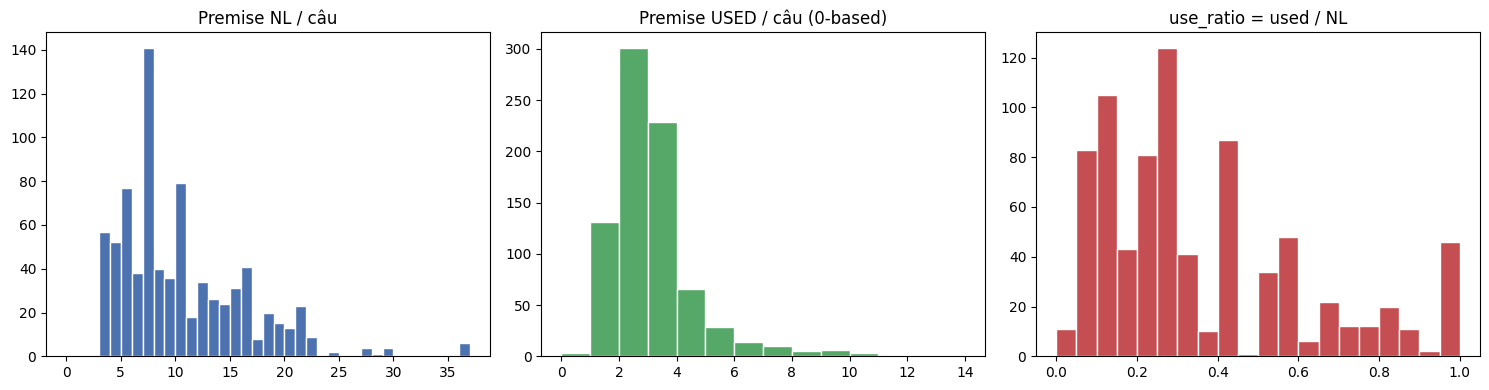

In [3]:
def stat(s, name):
    s = s.dropna()
    print(f"{name}: mean={s.mean():.2f} P50={s.median():.0f} P90={s.quantile(.9):.0f} P99={s.quantile(.99):.0f} max={s.max():.0f}")
for sp in ("train", "dev", "test", "ALL"):
    sub = df if sp == "ALL" else df[df["split"] == sp]
    print(f"\n--- [{sp}] n={len(sub)} ---")
    stat(sub["n_premises_nl"],   "premise NL  /câu")
    stat(sub["n_premises_fol"],  "premise FOL /câu")
    stat(sub["n_premises_used"], "premise USED/câu")
    stat(sub["use_ratio"],       "use_ratio       ")
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df["n_premises_nl"], bins=range(0, int(df["n_premises_nl"].max())+2), color="#4C72B0", edgecolor="white"); ax[0].set_title("Premise NL / câu")
ax[1].hist(df["n_premises_used"], bins=range(0, int(df["n_premises_used"].max())+2), color="#55A868", edgecolor="white"); ax[1].set_title("Premise USED / câu (0-based)")
ax[2].hist(df["use_ratio"].dropna(), bins=20, color="#C44E52", edgecolor="white"); ax[2].set_title("use_ratio = used / NL")
plt.tight_layout(); plt.show()

## 2. Phân phối nhãn (answer_label) & loại câu — toàn bộ + theo split

Answer label (toàn bộ): {'Yes': 313, 'A': 190, 'No': 80, 'B': 70, 'C': 59, 'Uncertain': 58, 'D': 29}
[MCQ] n=348  label={'A': 190, 'B': 70, 'C': 59, 'D': 29}
[Yes/No/Uncertain] n=451  label={'Yes': 313, 'No': 80, 'Uncertain': 58}

Bảng nhãn × split:
            train  dev  test
A            153   19    18
B             53    7    10
C             45    5     9
D             21    2     6
Yes          272   18    23
No            58   16     6
Uncertain     41   11     6
TỔNG         643   78    78
Thiếu nhãn: KHÔNG — đủ 7 nhãn ở cả 3 split ✅


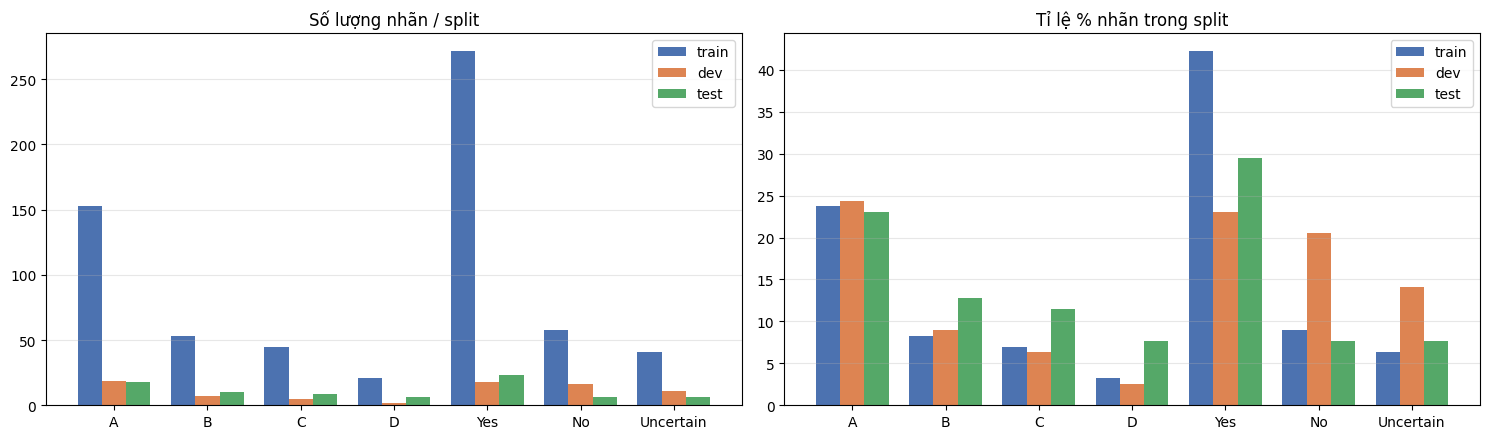

In [4]:
print("Answer label (toàn bộ):", dict(df["label"].value_counts()))
for t in ("MCQ", "Yes/No/Uncertain", "Open/Other"):
    sub = df[df["q_type"] == t]
    if len(sub): print(f"[{t}] n={len(sub)}  label={dict(sub['label'].value_counts())}")
dist = {sp: [int((df[df['split']==sp]['label'] == l).sum()) for l in HARD] for sp in ("train","dev","test")}
tbl = pd.DataFrame(dist, index=HARD); tbl.loc["TỔNG"] = tbl.sum()
print("\nBảng nhãn × split:\n", tbl)
miss = {sp: [HARD[i] for i, v in enumerate(dist[sp]) if v == 0] for sp in dist}
print("Thiếu nhãn:", {k: v for k, v in miss.items() if v} or "KHÔNG — đủ 7 nhãn ở cả 3 split ✅")
xx = np.arange(len(HARD)); w = 0.26; cols = {"train":"#4C72B0","dev":"#DD8452","test":"#55A868"}
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for k, sp in enumerate(("train","dev","test")):
    ax[0].bar(xx+(k-1)*w, dist[sp], w, label=sp, color=cols[sp])
    tot = sum(dist[sp]) or 1
    ax[1].bar(xx+(k-1)*w, [100*v/tot for v in dist[sp]], w, label=sp, color=cols[sp])
for a, ti in zip(ax, ("Số lượng nhãn / split", "Tỉ lệ % nhãn trong split")):
    a.set_xticks(xx); a.set_xticklabels(HARD); a.set_title(ti); a.legend(); a.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Reasoning steps — số step, prefix, 1-Conclusion

Tổng step: 4317 trên 799 câu có reasoning
Step/câu: mean=5.4 P50=5 P90=7 max=16
Prefix: {'Rule': 1286, 'Derive': 1393, 'Conclusion': 799, 'Fact': 839}
Đúng 1 Conclusion: 799/799 | !=1: 0
Step có 'premise N': 17
reasoning.type: {'fol': 799}


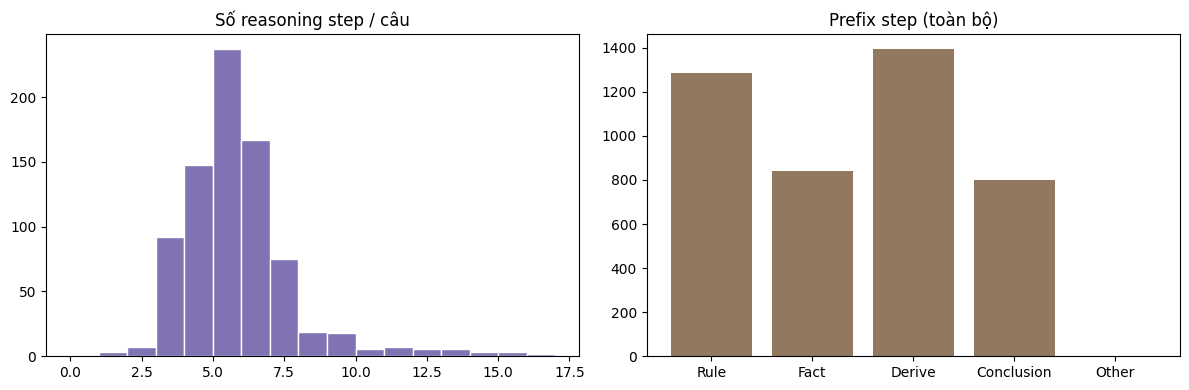

In [5]:
PREFIXES = ("Rule", "Fact", "Derive", "Conclusion")
def pref(s):
    for p in PREFIXES:
        if s.startswith(p + ":"): return p
    return "Other"
wr = df[df["has_reasoning"]]
steps = [s for r in wr["reasoning"] for s in r["steps"]]
pc = Counter(pref(s) for s in steps)
n_concl = wr["reasoning"].apply(lambda r: sum(1 for s in r["steps"] if s.startswith("Conclusion:")))
n_num = sum(1 for s in steps if re.search(r"(?i)\bpremise\s+\d", s))
print(f"Tổng step: {len(steps)} trên {len(wr)} câu có reasoning")
print(f"Step/câu: mean={wr['n_steps'].mean():.1f} P50={wr['n_steps'].median():.0f} P90={wr['n_steps'].quantile(.9):.0f} max={wr['n_steps'].max():.0f}")
print("Prefix:", dict(pc))
print(f"Đúng 1 Conclusion: {int((n_concl==1).sum())}/{len(wr)} | !=1: {int((n_concl!=1).sum())}")
print(f"Step có 'premise N': {n_num}")
print("reasoning.type:", dict(wr["reasoning_type"].value_counts()))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(wr["n_steps"], bins=range(0, int(wr["n_steps"].max())+2), color="#8172B3", edgecolor="white"); ax[0].set_title("Số reasoning step / câu")
pf = pd.Series(pc).reindex(list(PREFIXES)+["Other"]).fillna(0); ax[1].bar(pf.index, pf.values, color="#937860"); ax[1].set_title("Prefix step (toàn bộ)")
plt.tight_layout(); plt.show()

## 4. Explanation cite ⊆ premises_used (0-based)

In [6]:
CITE = re.compile(r"[Pp]remises?\s+(\d+(?:\s*(?:,\s*and\s*|,\s*|\s+and\s+|\s*&\s*)\d+)*)")
def nums(e): return [int(x) for g in CITE.findall(str(e)) for x in re.findall(r"\d+", g)]
sub_ok = within = total = rows_c = 0
for _, r in df.iterrows():
    ns = nums(r["explanation"])
    if not ns: continue
    rows_c += 1; pu = set(r["premises_used"] or [])
    for n in ns: total += 1; within += (n in pu)
    sub_ok += (set(ns) <= pu)
print(f"Câu có cite premise: {rows_c}/{len(df)}")
print(f"Cite ∈ premises_used: {within}/{total} = {within/max(total,1):.1%}")
print(f"Câu cite ⊆ premises_used: {sub_ok}/{rows_c} = {sub_ok/max(rows_c,1):.1%}")
print("(explanation có thể cite premise của đáp án SAI -> subset < 100% là bình thường)")

Câu có cite premise: 755/799
Cite ∈ premises_used: 2620/2755 = 95.1%
Câu cite ⊆ premises_used: 671/755 = 88.9%
(explanation có thể cite premise của đáp án SAI -> subset < 100% là bình thường)


## 5a. Phân phối ĐỘ DÀI — word-count (không cần lib)

[train] input words: mean=202 P50=184 P95=374 max=605 | step words: mean=48 P95=80
[dev  ] input words: mean=190 P50=134 P95=455 max=597 | step words: mean=42 P95=67
[test ] input words: mean=199 P50=173 P95=383 max=623 | step words: mean=48 P95=81
[ALL  ] input words: mean=201 P50=178 P95=382 max=623 | step words: mean=47 P95=79


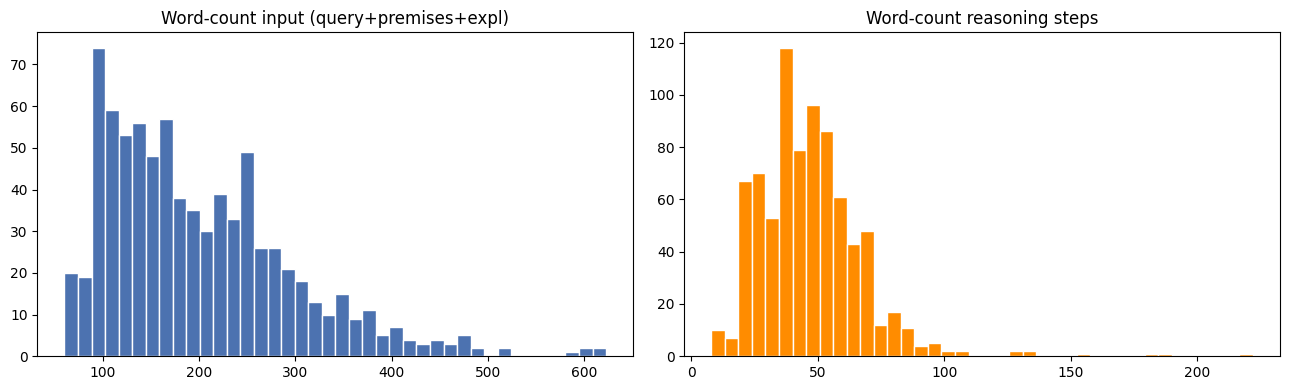

In [7]:
def wc(r):
    body = str(r["query"]) + " " + " ".join(r["premises"]) + " " + str(r["explanation"])
    steps = " ".join(r["reasoning"]["steps"]) if r["reasoning"] and r["reasoning"].get("steps") else ""
    return len(body.split()), len(steps.split())
wcs = df.apply(wc, axis=1, result_type="expand"); df["wc_input"], df["wc_steps"] = wcs[0], wcs[1]
for sp in ("train", "dev", "test", "ALL"):
    sub = df if sp == "ALL" else df[df["split"] == sp]; s, t = sub["wc_input"], sub["wc_steps"]
    print(f"[{sp:5}] input words: mean={s.mean():.0f} P50={s.median():.0f} P95={s.quantile(.95):.0f} max={s.max()} | step words: mean={t.mean():.0f} P95={t.quantile(.95):.0f}")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["wc_input"], bins=40, color="#4C72B0", edgecolor="white"); ax[0].set_title("Word-count input (query+premises+expl)")
ax[1].hist(df["wc_steps"], bins=40, color="darkorange", edgecolor="white"); ax[1].set_title("Word-count reasoning steps")
plt.tight_layout(); plt.show()

## 5b. Phân phối ĐỘ DÀI — token QA-SFT (cần tokenizer Qwen)

c:\Users\ASUS\anaconda3\envs\DS310_env_3_10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer: Qwen/Qwen3.5-4B | max_seq=3000 | gen_max_new_tokens=1000
SYSTEM_PROMPT tokens: 1269
[full SFT] mean=1977 P50=1949 P95=2458 P99=2757 max=3397
[assistant (answer LAST)] mean=239 P50=214 P95=450 P99=559 max=751
% assistant > gen_max(1000): 0.00%  (answer ở cuối -> cắt = mất answer!)
% full > max_seq(3000): 0.25%


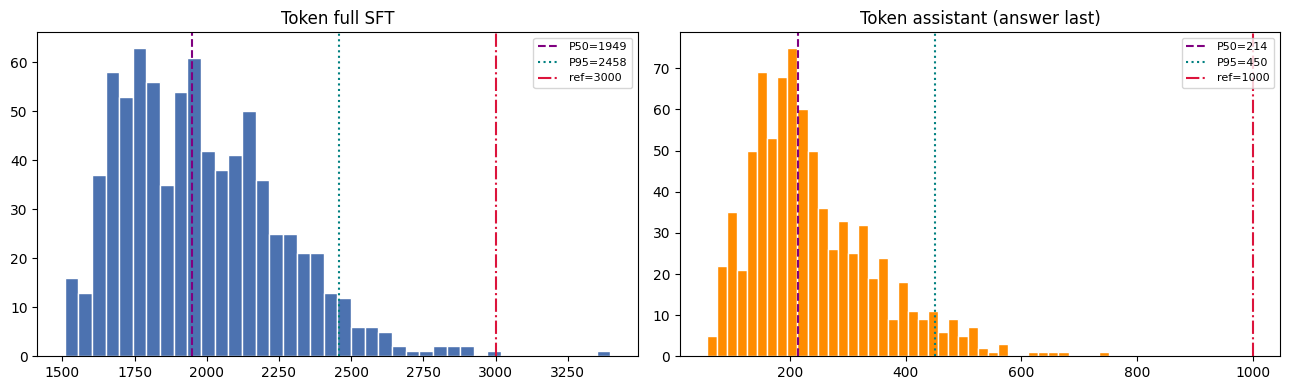

In [8]:
try:
    import yaml
    from transformers import AutoTokenizer
    from models.QA_model.prepare_data import SYSTEM_PROMPT_QA_COT, build_messages_for_sample
    cfg = yaml.safe_load((ROOT / "configs" / "qa_model.yaml").read_text(encoding="utf-8"))
    mname = (cfg.get("model") or {}).get("name", "Qwen/Qwen3-4B")
    max_seq = (cfg.get("model") or {}).get("max_seq_length", 3500); gen_max = (cfg.get("model") or {}).get("gen_max_new_tokens", 768)
    print(f"Tokenizer: {mname} | max_seq={max_seq} | gen_max_new_tokens={gen_max}")
    tok = AutoTokenizer.from_pretrained(mname, trust_remote_code=True)
    print("SYSTEM_PROMPT tokens:", len(tok.encode(SYSTEM_PROMPT_QA_COT, add_special_tokens=False)))
    recs = []
    for _, r in df.iterrows():
        if not (r["reasoning"] and r["reasoning"].get("steps")): continue
        try:
            m = build_messages_for_sample(premises_nl=r["premises"], premises_fol=r["premises_fol"], question=str(r["query"]),
                                          answer=str(r["answer"]), explanation=str(r["explanation"]),
                                          reasoning_steps=r["reasoning"]["steps"], premises_used=r["premises_used"], options=r["options"])
            full = tok.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
            recs.append({"split": r["split"], "n_full": len(tok.encode(full, add_special_tokens=False)),
                         "n_asst": len(tok.encode(m[2]["content"], add_special_tokens=False))})
        except Exception: continue
    dft = pd.DataFrame(recs)
    for col, name in [("n_full", "full SFT"), ("n_asst", "assistant (answer LAST)")]:
        s = dft[col]; print(f"[{name}] mean={s.mean():.0f} P50={s.quantile(.5):.0f} P95={s.quantile(.95):.0f} P99={s.quantile(.99):.0f} max={s.max()}")
    print(f"% assistant > gen_max({gen_max}): {100*(dft['n_asst']>gen_max).mean():.2f}%  (answer ở cuối -> cắt = mất answer!)")
    print(f"% full > max_seq({max_seq}): {100*(dft['n_full']>max_seq).mean():.2f}%")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for a, col, color, title, ref in [(ax[0],"n_full","#4C72B0","Token full SFT",max_seq), (ax[1],"n_asst","darkorange","Token assistant (answer last)",gen_max)]:
        s = dft[col]; a.hist(s, bins=40, color=color, edgecolor="white")
        a.axvline(s.median(), color="purple", ls="--", label=f"P50={s.median():.0f}"); a.axvline(s.quantile(.95), color="teal", ls=":", label=f"P95={s.quantile(.95):.0f}"); a.axvline(ref, color="crimson", ls="-.", label=f"ref={ref}"); a.set_title(title); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"[skip] tokenizer/prepare_data lỗi: {type(e).__name__}: {e}. Dùng phần 5a (word-count) để xem độ dài.")